# Final Project

## Summary 

#### 1. Major Findings 

Overall, the models showed that the input variables were able to explain some of the variation in transformed track popularity, but they were all still limited. As the models got more complex, their improvements were relatively minimal. Model 6 performed the best on the training data with the highest R-squared value and the lowest RMSE value. However, after using cross-validation, Model 4 was identified as the better model because it performed very similarly to Model 6 while being much less complex. This means that adding the interactions and quadratic transformations in Model 6 did not improve the prediction performance enough to justify keeping the additional terms. 

#### 2. Which inputs/features seem to influence the response/outcome the most? What direction is their effect, i.e., as they increase or otherwise change value, what happens to the outcome variable?

The main inputs that seemed to influence the transformed track popularity variable were `playlist_subgenre`, `energy`, and `loudness`. To be specific, the classic rock and permanent wave subgenres consistently had positive statistically significant coefficients compared with the reference subgenre, album rock. With the continuous variables, `energy` had a negative effect, meaning that as `energy` increased, the predicted transformed track popularity tended to decrease. On the other hand, `loudness` had a positive effect, meaning that as `loudness` increased, the predicted transformed track popularity tended to increase. Other features like `instrumentalness` and `valence` tended to have negative statistically significant effects, while `danceability` tended to have a positive effect. `Tempo` was statistically significant in Model 3, but was not in the following models once other inputs were added.

#### 3. Looking back at your EDA assignment, did the associations between variables found by predictive modeling align with what you found in the EDA?

The associations between variables found by predictive modeling partially aligned with what I found in the EDA project. In the EDA project, I found that energy had a slight negative correlation with the transformed track popularity variable, but that correlation was not very clear visually in the scatterplot. The predictive models helped provide more evidence because `energy` consistently had a negative statistically significant coefficient when other inputs were added. `Danceability` and `loudness` had slight positive correlations with popularity in the EDA, which remained consistent in the predictive models. However, the predictive modeling helped confirm these relationships with its coefficients, p-values, and confidence intervals. `Tempo` appeared to have little to no correlation with popularity which remained consistent with the predictive modeling as more inputs were added. 

#### 4. What skills did you learn from going through this project? What skills, if any, can you take away from the project to apply to applications more specific to an area of interest for you?

Through this project, I was able to strengthen many of the skills and concepts that I learned throughout the course. I gained more practice building and comparing multiple linear regression models with different goals and levels of complexity. I gained confidence in interpreting regression coefficients, p-values, confidence intervals, R-squared, and RMSE values. The project also gave me more experience applying feature transformations, interactions, standardization, prediction visualizations, and cross-validation. One of the most important things that I can take away from this project is actually the result of cross-validating. I learned that even though a model may have lower training error, a different model with similar performance but less complexity can be the better option. I can apply all of these skills to future data science projects where I would need to explore, evaluate, and model data. 

## Model Fitting and Interpretation 

### Standardization of Continuous Variables

In [397]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from statsmodels.tools.eval_measures import rmse
from patsy import dmatrices

##### Import necessary packages for the final project.

In [398]:
# Load in spotify_songs.csv file
spotify_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv "
df = pd.read_csv(spotify_url)

# Create transformed outcome variable
df['track_popularity_shifted'] = np.where(df.track_popularity == 100, df.track_popularity - 0.1, df.track_popularity)  
df['track_popularity_shifted'] = np.where(df.track_popularity == 0, df.track_popularity + 0.1, df.track_popularity_shifted)  
df['track_popularity_fraction'] = df.track_popularity_shifted/100
df['track_popularity_transformed'] = np.log(df.track_popularity_fraction / (1 - df.track_popularity_fraction)) 

# Drop:
#      Unecessary variables created for the transformed outcome variable. 
#      Uncessary continuous variables that were not explored.
#      Transformed outcome variabe to standardize continuous variables.
df_inputs = df.drop(columns=['track_popularity', 'track_popularity_shifted', 'track_popularity_fraction', 'duration_ms', 'key','mode',
                      'speechiness', 'acousticness', 'liveness', 'track_popularity_transformed'])

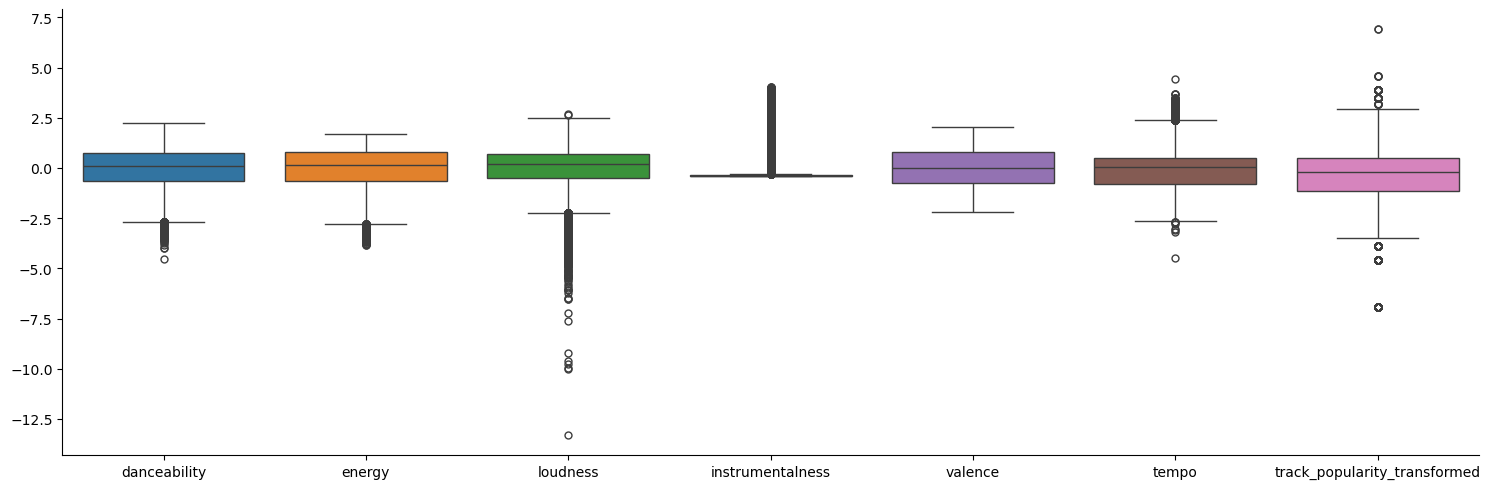

In [399]:
# Standardization of continuous variables
df_cont_inputs = df_inputs.select_dtypes('number') 
df_scaler = StandardScaler() # initialize scaler
df_std_arr = df_scaler.fit_transform(df_cont_inputs) # do the standardization
df_std = pd.DataFrame(df_std_arr, columns=df_cont_inputs.columns) # create a df from NumPy arr

# Add playlist variables and the transformed outcome variable back into the dataframe with the standardized variables
df_std['playlist_genre'] = df['playlist_genre']
df_std['playlist_subgenre'] = df['playlist_subgenre']
df_std['track_popularity_transformed'] = df['track_popularity_transformed']

# Plot standardized variables including the trnasformed outcome variable.
sns.catplot(df_std, kind='box', aspect=3)
plt.show()

### Model 1: Intercept-Only

In [400]:
model_name = 'Intercept-Only'
model_formula = 'track_popularity_transformed ~ 1'

model = smf.ols(model_formula, data=df_std).fit()
print(model.params, '\n')
print(model.pvalues < 0.05)

Intercept   -0.827397
dtype: float64 

Intercept    True
dtype: bool


#### 1. How many coefficients were estimated?

In Model 1, there were only one coefficient that was estimated, including the intercept.

#### 2. WHICH coefficients are STATISTICALLY SIGNIFICANT and are the coefficients POSITIVE or NEGATIVE for those features?

In [401]:
model.conf_int()

,0,1
Intercept,-0.851328,-0.803466


The intercept is statistically significant because its p-value is less than 0.05. The intercept coefficient is negative, meaning that the estimated mean of the transformed outcome variable is negative. Because the intercept coefficient is statistically significant, the confidence interval should not include 0 and we can see that it does not.

#### 3. WHICH two STATISTICALLY SIGNIFICANT coefficients have the highest MAGNITUDE coefficient values?

The intercept coefficient is the only estimated coefficient, meaning there can't be any comparisons made for the feature coefficients. 

#### 4. Calculate the r-squared and RMSE of the model on the entire dataset.

In [402]:
# Calculate R-squared
model_rsquared = model.rsquared
print("R squared:", model_rsquared)

# Calculate RMSE
preds = model.predict(df_std)
model_rmse = rmse(df_std.track_popularity_transformed, preds)
print("RMSE:", model_rmse)

# Store performance metrics from the different models in a DataFrame.
model_performance_lines = []
model_intercept_eval = {'name': model_name,
                        'formula': model_formula,
                        'r_squared': model_rsquared, 
                        'rmse': model_rmse,
                       }
model_performance_lines.append(model_intercept_eval)

R squared: 0.0
RMSE: 2.212308770791808


The intercept-only model has an R-squared of 0.0 because it uses no input features, so it is only predicting its overall mean for every observation. This R-squared will be the baseline for the rest of the models. The model has an RMSE of ~2.212, meaning that its predictions differ from the actual transformed track popularity values by about 2.212 units. 

#### 5. Predicted vs Observed Figure

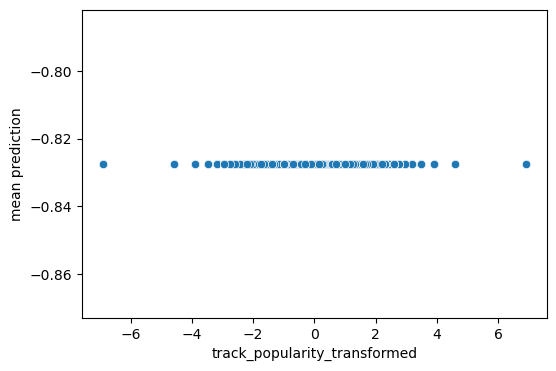

In [403]:
fig, ax = plt.subplots(figsize=(6,4))

# Scatterplot of training data
sns.scatterplot(data=df_std, x="track_popularity_transformed", y=preds, ax=ax)

# Set the y-axis label
ax.set_ylabel("mean prediction")

plt.show()

Because this model only uses the intercept and no features, the predicted mean will stay consistent, making the plot appear to be a horizontal line. 

### Model 2: Categorical Inputs with Additive Features

In [404]:
model_name = 'Categorical Inputs with Additive Features'
model_formula = 'track_popularity_transformed ~ playlist_genre + playlist_subgenre'

model = smf.ols(model_formula, data=df_std).fit()
print(model.params, '\n')
print(model.pvalues < 0.05 )

Intercept                                         6.715216e+10
playlist_genre[T.latin]                          -1.313146e+10
playlist_genre[T.pop]                             1.150836e+10
playlist_genre[T.r&b]                            -3.619986e+10
playlist_genre[T.rap]                            -4.890530e+09
playlist_genre[T.rock]                           -6.715216e+10
playlist_subgenre[T.big room]                    -6.715216e+10
playlist_subgenre[T.classic rock]                 2.442083e-01
playlist_subgenre[T.dance pop]                   -7.866052e+10
playlist_subgenre[T.electro house]               -6.715216e+10
playlist_subgenre[T.electropop]                  -7.866052e+10
playlist_subgenre[T.gangster rap]                -6.226163e+10
playlist_subgenre[T.hard rock]                   -1.088800e-01
playlist_subgenre[T.hip hop]                     -6.226163e+10
playlist_subgenre[T.hip pop]                     -3.095230e+10
playlist_subgenre[T.indie poptimism]             -7.866

#### 1. How many coefficients were estimated?

In Model 2, there were 29 total coefficients estimated, including the intercept.

#### 2. WHICH coefficients are STATISTICALLY SIGNIFICANT and are the coefficients POSITIVE or NEGATIVE for those features?

In [405]:
print(model.conf_int().loc["playlist_subgenre[T.classic rock]"], '\n')
print(model.conf_int().loc["playlist_subgenre[T.permanent wave]"])

0    0.072763
1    0.415653
Name: playlist_subgenre[T.classic rock], dtype: float64 

0    1.061950
1    1.417957
Name: playlist_subgenre[T.permanent wave], dtype: float64


There were only two coefficients that were statistically significant: classic rock and permanent wave from `playlist_subgenre`. Both of the coefficients are positive. These coefficients were only statistically significant based on the references that were chosen. The references that were chosen were edm, from `playlist_genre`, and album rock, from `playlist_subgenre`. This means that only classic rock and permanent wave differed significantly in expected track popularity from album rock. There were no `playlist_genre` coefficients that were statistically significant in reference to the edm genre. We can see that both confidence intervals do not contain 0, which is consistent that both subgenres are statistically significant.

#### 3. WHICH two STATISTICALLY SIGNIFICANT coefficients have the highest MAGNITUDE coefficient values?

There were only two statistically significant coefficients, so those two coefficients have the highest magnitudes of 0.244 for classic rock and 1.24 for permanent wave.

#### 4. Calculate the r-squared and RMSE of the model on the entire dataset, which you used for training the model (later you will use cross-validation to protect against overfitting).

In [406]:
# Calculate R-squared
model_rsquared = model.rsquared
print("R squared:", model_rsquared)

# Calculate RMSE
preds = model.predict(df_std)
model_rmse = rmse(df_std.track_popularity_transformed, preds)
print("RMSE:", model_rmse)

# Store performance metrics from the different models in a DataFrame.
model_intercept_eval = {'name': model_name,
                        'formula': model_formula,
                        'r_squared': model_rsquared, 
                        'rmse': model_rmse,
                       }
model_performance_lines.append(model_intercept_eval)

R squared: 0.08692950300396707
RMSE: 2.1139655042159107


The categorical input model has an R-squared of approximately 0.087, meaning that the model explains about 8.7% of the variation in the outcome variable. This means that the categorical inputs alone are limited in explaining the transformed track popularity. The model has an RMSE of about 2.114 meaning that its predictions differ from the actual values by about 2.114 units. 

#### 5. Plot a predicted vs observed figure.

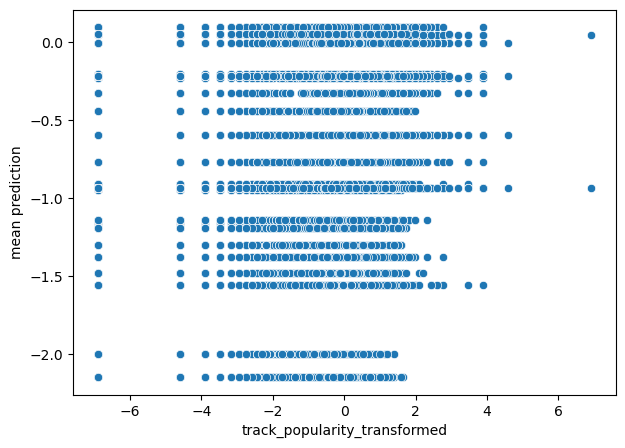

In [407]:
fig, ax = plt.subplots(figsize=(7,5))

# Scatterplot of training data
sns.scatterplot(data=df_std, x="track_popularity_transformed", y=preds, ax=ax)

# Set the y-axis label
ax.set_ylabel("mean prediction")

plt.show()

The plot seems to show multiple horizontal lines. This is because the observations are separated by categorical groups, so the observations will get the same predicted value which forms the line. We can see that the scale of both the predicted and observed values are much different. The observed values range between -7 to 7 while the predicted values sit between 0.1 to -2.2. This is consistent with the low R-squared value and aligns with the idea that the categorical inputs alone are limited in explaining the transformed track popularity. 

### Model 3: Continuous Inputs with Additive Features

In [408]:
model_name = 'Continuous Inputs with Additive Features'
model_formula = 'track_popularity_transformed ~ danceability + energy + loudness + instrumentalness + valence + tempo'

model = smf.ols(model_formula, data=df_std).fit()
print(model.params, '\n')
print(model.pvalues < 0.05)

Intercept          -0.827397
danceability        0.070137
energy             -0.472158
loudness            0.346678
instrumentalness   -0.184707
valence             0.028178
tempo               0.041534
dtype: float64 

Intercept           True
danceability        True
energy              True
loudness            True
instrumentalness    True
valence             True
tempo               True
dtype: bool


#### 1. How many coefficients were estimated?

In Model 3, there were 7 total coefficients estimated, including the intercept.

#### 2. WHICH coefficients are STATISTICALLY SIGNIFICANT and are the coefficients POSITIVE or NEGATIVE for those features?

In [409]:
model.conf_int()

,0,1
Intercept,-0.850860,-0.803934
danceability,0.044225,0.096049
energy,-0.506160,-0.438156
loudness,0.313227,0.380129
instrumentalness,-0.209497,-0.159916
valence,0.001996,0.054360
tempo,0.017426,0.065642


All 7 coefficients, including the intercept, are statistically significant because their p-values were less than 0.05. The intercept, energy, and instrumentalness coefficients were negative while the danceability, loudness, valence, and tempo coefficients were positive. We can also see that the confidence intervals for each coefficient do not contain 0 which is consistent with them being statistically significant. 

#### 3. WHICH two STATISTICALLY SIGNIFICANT coefficients have the highest MAGNITUDE coefficient values?

The `energy` and `loudness` features had the highest magnitude coefficient values with magnitudes of approximately 0.472 and 0.347, respectively. 

#### 4. Calculate the r-squared and RMSE of the model on the entire dataset, which you used for training the model (later you will use cross-validation to protect against overfitting).

In [410]:
# Calculate R-squared
model_rsquared = model.rsquared
print("R squared:", model_rsquared)

# Calculate RMSE
preds = model.predict(df_std)
model_rmse = rmse(df_std.track_popularity_transformed, preds)
print("RMSE:", model_rmse)

# Store performance metrics from the different models in a DataFrame.
model_intercept_eval = {'name': model_name,
                        'formula': model_formula,
                        'r_squared': model_rsquared, 
                        'rmse': model_rmse,
                       }
model_performance_lines.append(model_intercept_eval)

R squared: 0.038929880435418784
RMSE: 2.1688188468426164


Even though all the coefficients were statistically significant, the continuous input model performed worse than the categorical model. With an R-squared of about 0.039, this model explains about 3.9% of the variation in the transformed outcome variable. The RMSE is also higher than the categorical model, at around 2.169, meaning that the predicted values differed from the observed values by about 2.169 units. 

#### 5. Plot a predicted vs observed figure.

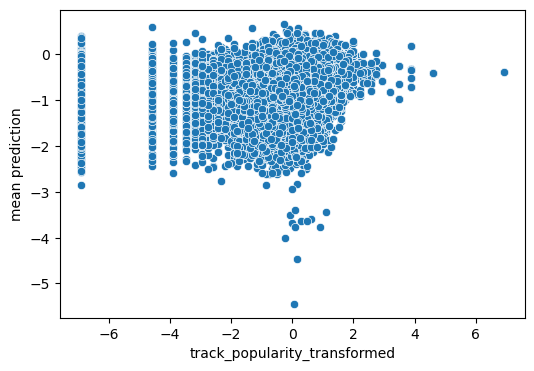

In [411]:
fig, ax = plt.subplots(figsize=(6,4))

# Scatterplot of training data
sns.scatterplot(data=df_std, x="track_popularity_transformed", y=preds, ax=ax)

# Set the y-axis label
ax.set_ylabel("mean prediction")

plt.show()

The plot seems to have a wider range for its predicted values than the categorical model because of its continuous features allowing for more variation. However, even with the wider range, it appears that many of the values are noticeably different which stays consistent with the R-squared and the RMSE values. The continuous inputs alone are also limited in explaining the transformed track popularity. 

### Model 4: All Inputs with Additive Features

In [412]:
model_name = 'All Inputs with Additive Features'
model_formula = ('track_popularity_transformed ~ '
                 'playlist_genre + playlist_subgenre + danceability + '
                 'energy + loudness + instrumentalness + valence + tempo'
                )

model = smf.ols(model_formula, data=df_std).fit()
print(model.params, '\n')
print(model.pvalues < 0.05 )

Intercept                                         8.984356e+10
playlist_genre[T.latin]                          -1.433533e+10
playlist_genre[T.pop]                             1.400132e+10
playlist_genre[T.r&b]                            -3.749019e+10
playlist_genre[T.rap]                             1.920866e+10
playlist_genre[T.rock]                           -8.984356e+10
playlist_subgenre[T.big room]                    -8.984356e+10
playlist_subgenre[T.classic rock]                 2.336602e-01
playlist_subgenre[T.dance pop]                   -1.038449e+11
playlist_subgenre[T.electro house]               -8.984356e+10
playlist_subgenre[T.electropop]                  -1.038449e+11
playlist_subgenre[T.gangster rap]                -1.090522e+11
playlist_subgenre[T.hard rock]                   -3.069743e-02
playlist_subgenre[T.hip hop]                     -1.090522e+11
playlist_subgenre[T.hip pop]                     -5.235336e+10
playlist_subgenre[T.indie poptimism]             -1.038

#### 1. How many coefficients were estimated?

In Model 4, there were 35 total estimated coefficients, including the intercept.

#### 2. WHICH coefficients are STATISTICALLY SIGNIFICANT and are the coefficients POSITIVE or NEGATIVE for those features?

In [413]:
print(model.conf_int().loc['playlist_subgenre[T.classic rock]'], '\n')
print(model.conf_int().loc['playlist_subgenre[T.permanent wave]'], '\n')
print(model.conf_int().loc['danceability'], '\n')
print(model.conf_int().loc['energy'], '\n')
print(model.conf_int().loc['loudness'], '\n')
print(model.conf_int().loc['instrumentalness'], '\n')
print(model.conf_int().loc['valence'], '\n')

0    0.064132
1    0.403189
Name: playlist_subgenre[T.classic rock], dtype: float64 

0    1.046448
1    1.398618
Name: playlist_subgenre[T.permanent wave], dtype: float64 

0    0.096684
1    0.152894
Name: danceability, dtype: float64 

0   -0.396667
1   -0.325886
Name: energy, dtype: float64 

0    0.227563
1    0.294745
Name: loudness, dtype: float64 

0   -0.209888
1   -0.158811
Name: instrumentalness, dtype: float64 

0   -0.056435
1   -0.002387
Name: valence, dtype: float64 



The two subgenres, classic rock and permanent wave, from the previous categorical input model are still statistically significant in this model. The 7 coefficients from the previous continuous input model, however, are not all statistically significant in this model. The `tempo` coefficient is not statistically significant. This model does also use the same two references: edm and album rock. This means that both of the subgenres, remain differing significantly in expected track popularity from album rock. Similarly to the categorical model, there are no `playlist_genre` coefficients that are statistically significant in reference to the edm genre. Although the `tempo` was statistically significant in the previous continuous input model, once the categorical inputs were added, it was no longer significant. Looking at the confidence intervals, we can see that they all do not contain 0, which is consistent with them being statistically significant. We can also see that the features `energy`, `instrumentalness` and `valence` have negative coefficients, while the other four features have positive coefficients.

#### 3. WHICH two STATISTICALLY SIGNIFICANT coefficients have the highest MAGNITUDE coefficient values?

The `energy` and `loudness` features had the highest magnitude coefficient values with magnitudes of approximately 0.361 and 0.261, respectively. 

#### 4. Calculate the r-squared and RMSE of the model on the entire dataset, which you used for training the model (later you will use cross-validation to protect against overfitting).

In [414]:
# Calculate R-squared
model_rsquared = model.rsquared
print("R squared:", model_rsquared)

# Calculate RMSE
preds = model.predict(df_std)
model_rmse = rmse(df_std.track_popularity_transformed, preds)
print("RMSE:", model_rmse)

# Store performance metrics from the different models in a DataFrame.
model_intercept_eval = {'name': model_name,
                        'formula': model_formula,
                        'r_squared': model_rsquared, 
                        'rmse': model_rmse,
                       }
model_performance_lines.append(model_intercept_eval)

R squared: 0.110545717283978
RMSE: 2.0864479569362957


Model 4 seems to have performed better than the previous three. With an R-squared of 0.111, this means that the model is able to explain 11.1% of the variation in the transformed outcome variable. The RMSE value sits around 2.086, meaning that the predicted values tend to differ from the actual values by about 2.086 units. 

#### 5. Plot a predicted vs observed figure.

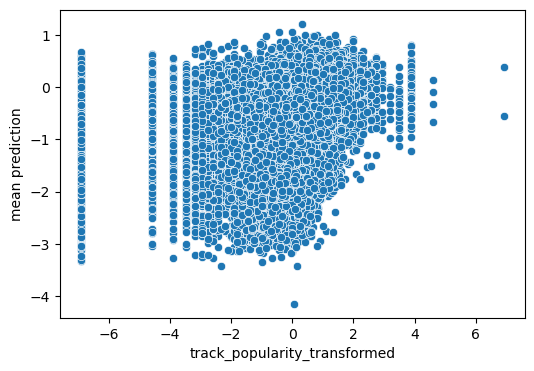

In [415]:
fig, ax = plt.subplots(figsize=(6,4))

# Scatterplot of training data
sns.scatterplot(data=df_std, x="track_popularity_transformed", y=preds, ax=ax)

# Set the y-axis label
ax.set_ylabel("mean prediction")

plt.show()

While this plot seems to look very similar to the continuous model, there is a wider range for the predicted values meaning that the model can account for more of the variation we see in the observed values which we can see reflected in the R-squared and RMSE values. There are still many predicted values that were noticeably different than the observed values. 

### Model 5: All Inputs with Pair-Wise Continuous Interactions

In [416]:
model_name = 'All Inputs with Pair-Wise Continuous Interactions'
model_formula = ('track_popularity_transformed ~ '
                 'playlist_genre + playlist_subgenre +'
                 '(danceability + energy + loudness + instrumentalness + valence + tempo) ** 2'
                )

model = smf.ols(model_formula, data=df_std).fit()
print(model.params, '\n')
print(model.pvalues < 0.05 )

Intercept                                         8.970372e+10
playlist_genre[T.latin]                          -1.442414e+10
playlist_genre[T.pop]                             1.427114e+10
playlist_genre[T.r&b]                            -4.562273e+10
playlist_genre[T.rap]                             2.135587e+10
playlist_genre[T.rock]                           -8.970372e+10
playlist_subgenre[T.big room]                    -8.970372e+10
playlist_subgenre[T.classic rock]                 2.603586e-01
playlist_subgenre[T.dance pop]                   -1.039749e+11
playlist_subgenre[T.electro house]               -8.970372e+10
playlist_subgenre[T.electropop]                  -1.039749e+11
playlist_subgenre[T.gangster rap]                -1.110596e+11
playlist_subgenre[T.hard rock]                   -6.371326e-02
playlist_subgenre[T.hip hop]                     -1.110596e+11
playlist_subgenre[T.hip pop]                     -4.408099e+10
playlist_subgenre[T.indie poptimism]             -1.039

#### 1. How many coefficients were estimated?

In Model 5, there were 50 coefficients estimated, including the intercept.

#### 2. WHICH coefficients are STATISTICALLY SIGNIFICANT and are the coefficients POSITIVE or NEGATIVE for those features?

There were many coefficients that were statistically significant. For the categorical inputs, the two subgenres, classic rock and permanent wave were again both statistically significant and were both positive coefficients. The same two references, edm and album rock, were used in this model. For the continuous inputs, all coefficients but `valence` and `tempo` were statistically significant. The `energy` and `instrumentalness` coefficients were both negative while the other two were positive. For the interactions, there were some coefficients that were statistically significant: danceability:valence(positive), energy:loudness(negative), energy:instrumentalness(positive), energy:valence(negative), loudness:instrumentalness(negative), and loudness:valence(positive).

#### 3. WHICH two STATISTICALLY SIGNIFICANT coefficients have the highest MAGNITUDE coefficient values?

The two statistically significant coefficients that have the highest magnitude coefficient values are playlist_subgenre[T.permanent wave] and energy with 1.220 and 0.371, respectively.

#### 4. Calculate the r-squared and RMSE of the model on the entire dataset, which you used for training the model (later you will use cross-validation to protect against overfitting).

In [417]:
# Calculate R-squared
model_rsquared = model.rsquared
print("R squared:", model_rsquared)

# Calculate RMSE
preds = model.predict(df_std)
model_rmse = rmse(df_std.track_popularity_transformed, preds)
print("RMSE:", model_rmse)

# Store performance metrics from the different models in a DataFrame.
model_intercept_eval = {'name': model_name,
                        'formula': model_formula,
                        'r_squared': model_rsquared, 
                        'rmse': model_rmse,
                       }
model_performance_lines.append(model_intercept_eval)

R squared: 0.11408996242518976
RMSE: 2.082286829959221


With an R-squared of 0.114, we can see that Model 5 performed slightly better than the previous model. This model is able to explain 11.4% of the variation in the transformed outcome variable. The RMSE value is around 2.082, meaning that the predicted values tend to differ from the observed values by about 2.082 units. 

#### 5. Plot a predicted vs observed figure.

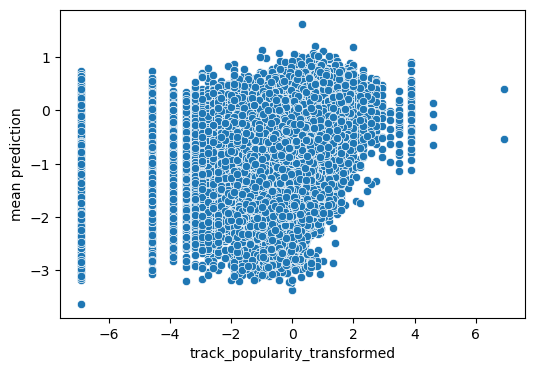

In [418]:
fig, ax = plt.subplots(figsize=(6,4))

# Scatterplot of training data
sns.scatterplot(data=df_std, x="track_popularity_transformed", y=preds, ax=ax)

# Set the y-axis label
ax.set_ylabel("mean prediction")

plt.show()

This plot seems to have a narrower range of predicted values than the previous model, but it performed better. This suggests that the model was unable to capture all of the variation in the observed values. However, we can see in the R-squared and RMSE values that the model performed better at predicting the values than the other models. 

### Model 6: All Inputs with Pair-Wise Interactions and Quadratic Transformations

In [419]:
model_name = 'All Inputs with Pair-Wise Interactions and Quadratic Transformations'
model_formula = ('track_popularity_transformed ~ '
    'playlist_genre + playlist_subgenre + '
    '(danceability + energy + loudness + instrumentalness + valence + tempo) ** 2 + '
    'np.power(danceability, 2) + '
    'np.power(energy, 2) + '
    'np.power(loudness, 2) + '
    'np.power(instrumentalness, 2) + '
    'np.power(valence, 2) + '
    'np.power(tempo, 2)'
)

model = smf.ols(model_formula, data=df_std).fit()
print(model.params, '\n')
print(model.pvalues < 0.05 )

Intercept                                         9.265555e+10
playlist_genre[T.latin]                          -1.379283e+10
playlist_genre[T.pop]                             1.443197e+10
playlist_genre[T.r&b]                            -5.141364e+10
playlist_genre[T.rap]                             2.405717e+10
playlist_genre[T.rock]                           -9.265555e+10
playlist_subgenre[T.big room]                    -9.265555e+10
playlist_subgenre[T.classic rock]                 2.736857e-01
playlist_subgenre[T.dance pop]                   -1.070875e+11
playlist_subgenre[T.electro house]               -9.265555e+10
playlist_subgenre[T.electropop]                  -1.070875e+11
playlist_subgenre[T.gangster rap]                -1.167127e+11
playlist_subgenre[T.hard rock]                   -6.480303e-02
playlist_subgenre[T.hip hop]                     -1.167127e+11
playlist_subgenre[T.hip pop]                     -4.124191e+10
playlist_subgenre[T.indie poptimism]             -1.070

#### 1. How many coefficients were estimated?

In Model 6, there were 56 coefficients estimated, including the intercept.

#### 2. WHICH coefficients are STATISTICALLY SIGNIFICANT and are the coefficients POSITIVE or NEGATIVE for those features?

There were many coefficients that were statistically significant. For the categorical inputs, the two subgenres, classic rock and permanent wave were again both statistically significant and were both positive coefficients. The same two references, edm and album rock, were used in this model. For the continuous inputs, all coefficients but `tempo` were statistically significant. The `energy`, `instrumentalness`, and `valence` coefficients were negative while the other two were positive. For the interactions, there were some coefficients that were statistically significant: danceability:valence(positive), energy:instrumentalness(positive), loudness:instrumentalness(negative), and loudness:valence(positive). For the quadratic coefficients, all but np.power(danceability, 2) and np.power(loudness, 2) were statistically significant. The negative coefficients were np.power(energy, 2) and np.power(valence, 2) while the other two were positive.

#### 3. WHICH two STATISTICALLY SIGNIFICANT coefficients have the highest MAGNITUDE coefficient values?

The two statistically significant coefficients that have the highest magnitude coefficient values are playlist_subgenre[T.permanent wave] and energy with 1.227 and 0.372, respectively.

#### 4. Calculate the r-squared and RMSE of the model on the entire dataset, which you used for training the model (later you will use cross-validation to protect against overfitting).

In [420]:
# Calculate R-squared
model_rsquared = model.rsquared
print("R squared:", model_rsquared)

# Calculate RMSE
preds = model.predict(df_std)
model_rmse = rmse(df_std.track_popularity_transformed, preds)
print("RMSE:", model_rmse)

# Store performance metrics from the different models in a DataFrame.
model_intercept_eval = {'name': model_name,
                        'formula': model_formula,
                        'r_squared': model_rsquared, 
                        'rmse': model_rmse,
                       }
model_performance_lines.append(model_intercept_eval)
len(model_performance_lines)

R squared: 0.11569407387381614
RMSE: 2.080400784310894


6

Model 6 seemed to perform slightly better than Model 5 with an R-squared value of 0.116. This means that the model was able to explain 11.6% of the variation in the transformed outcome variable. The RMSE value of 2.080 means that the predicted values tend to differ from the observed values by about 2.080 units. 

#### 5. Plot a predicted vs observed figure.

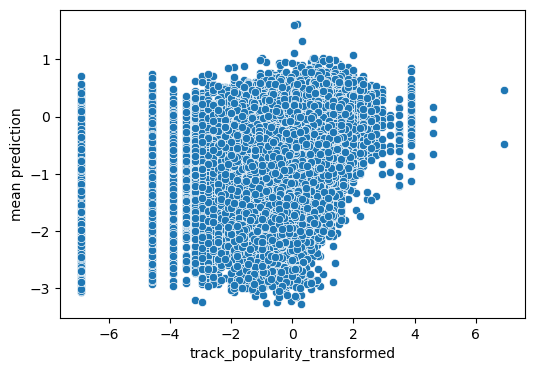

In [421]:
fig, ax = plt.subplots(figsize=(6,4))

# Scatterplot of training data
sns.scatterplot(data=df_std, x="track_popularity_transformed", y=preds, ax=ax)

# Set the y-axis label
ax.set_ylabel("mean prediction")

plt.show()

The plot for Model 6 looks nearly identical to the plot for Model 5. This is consistent with the small difference between their R-squared and RMSE values. Only in Model 6, with the addition of the nonlinear transformations, we can see that the model improves slightly in performance. 

### Summary

In [428]:
# Print final Data Frame
model_performance = pd.DataFrame(model_performance_lines)
model_performance

,name,formula,r_squared,rmse
0,Intercept-Only,track_popularity_transformed ~ 1,0.000000,2.212309
1,Categorical Inputs with Additive Features,track_popularity_transformed ~ playlist_genre ...,0.086930,2.113966
2,Continuous Inputs with Additive Features,track_popularity_transformed ~ danceability + ...,0.038930,2.168819
3,All Inputs with Additive Features,track_popularity_transformed ~ playlist_genre ...,0.110546,2.086448
4,All Inputs with Pair-Wise Continuous Interactions,track_popularity_transformed ~ playlist_genre ...,0.114090,2.082287
5,All Inputs with Pair-Wise Interactions and Qua...,track_popularity_transformed ~ playlist_genre ...,0.115694,2.080401


#### 1. Which model has the best performance on the training set? Describe which features the model used, don't just give a number to refer to the model.

The model with the best performance on the training set was Model 6 that used all inputs, pair-wise interactions, and quadratic transformations. The categorical inputs were `playlist_genre`, and `playlist_subgenre`, while the continuous inputs were `danceability`, `energy`, `loudness`, `instrumentalness`, `valence` and `tempo`. All of the continuous inputs were used for the pair-wise interactions and the quadratic transformations.

#### 2. Is the best model according to R-squared the SAME as the best model according to RMSE?

Yes, Model 6 has both the best R-squared and RMSE values, with the highest R-squared value at 0.116 and the lowest RMSE value at 2.080.

#### 3. Is the best model better than the INTERCEPT-ONLY model? How many coefficients are associated with the BEST model?

Yes, Model 6 is better than the intercept-only model. Model 6 estimated a total of 56 coefficients, including the intercept, while Model 1 (intercept-only) estimated only the intercept coefficient.

## Model Predictions 

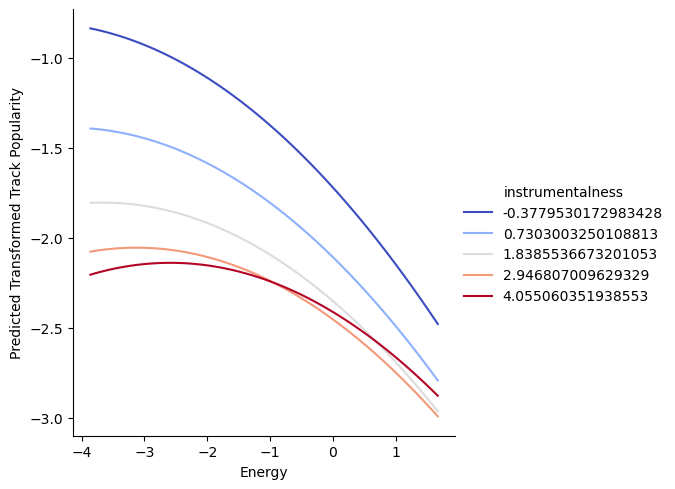

In [423]:
# Create prediction visualization grid for the energy and instrumentalness features
viz_grid = pd.DataFrame(
    [(energy, instrumentalness)
        for energy in np.linspace(df_std.energy.min(), df_std.energy.max(), 101)
        for instrumentalness in np.linspace(df_std.instrumentalness.min(), df_std.instrumentalness.max(), 5)
    ],
    columns=['energy', 'instrumentalness']
)

# Set all other inputs in the model to constant values
viz_grid['danceability'] = df_std.danceability.mean()
viz_grid['loudness'] = df_std.loudness.mean()
viz_grid['valence'] = df_std.valence.mean()
viz_grid['tempo'] = df_std.tempo.mean()
viz_grid['playlist_genre'] = df_std.playlist_genre.mode()[0]
viz_grid['playlist_subgenre'] = df_std.playlist_subgenre.mode()[0]

# Perform the predictions
viz_grid['pred'] = model.predict(viz_grid)

# Visualization
sns.relplot(
    data=viz_grid,
    x='energy',
    y='pred',
    kind='line',
    hue='instrumentalness',
    palette='coolwarm'
)

# Set both axis labels
plt.xlabel('Energy')
plt.ylabel('Predicted Transformed Track Popularity')

plt.show()

The plot shows that the predicted transformed track popularity generally decreases as energy increases. The lines are curved because of the quadratic transformations that were used in Model 6. At different levels of instrumentalness, we can see the relationship changes with the slopes of lines changing and even some lines crossing one another. This is consistent with the interaction between energy and instrumentalness being statistically significant. This means that the relationship between energy and predicted track popularity depends on the level of instrumentalness.

## Model Generalization Performance with Cross-Validation 

### Model 3

In [424]:
# Create design matrix
y_feature, x_features = dmatrices('track_popularity_transformed ~ danceability +'
                                  'energy + loudness + instrumentalness + valence + tempo', data=df)

# Create the pipeline
pipeline = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

# Split into 10 folds
kf = KFold(n_splits=10, shuffle=True, random_state=9)

# Run cross-validation and return RMSE for each fold
scores3 = -cross_val_score(pipeline, x_features, y_feature.ravel(), cv=kf, scoring='neg_root_mean_squared_error')
scores3.mean()

np.float64(2.1690285998654244)

### Model 4

In [425]:
# Create design matrix
y_feature, x_features = dmatrices('track_popularity_transformed ~ playlist_genre +'
                                  'playlist_subgenre + danceability + energy + loudness +'
                                  'instrumentalness + valence + tempo', data=df)

# Create the pipeline
pipeline = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

# Split into 10 folds
kf = KFold(n_splits=10, shuffle=True, random_state=9)

# Run cross-validation and return RMSE for each fold
scores4 = -cross_val_score(pipeline, x_features, y_feature.ravel(), cv=kf, scoring='neg_root_mean_squared_error')
scores4.mean()

np.float64(2.0880135503249884)

### Model 6

In [426]:
# Create design matrix
y_feature, x_features = dmatrices('track_popularity_transformed ~ playlist_genre +'
                                  'playlist_subgenre + (danceability + energy + loudness +'
                                  'instrumentalness + valence + tempo) ** 2 + np.power(danceability, 2) +'
                                  'np.power(energy, 2) + np.power(loudness, 2) + np.power(instrumentalness, 2) +'
                                  'np.power(valence, 2) + np.power(tempo, 2)', data=df)

# Create the pipeline
pipeline = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

# Split into 10 folds
kf = KFold(n_splits=10, shuffle=True, random_state=9)

# Run cross-validation and return RMSE for each fold
scores6 = -cross_val_score(pipeline, x_features, y_feature.ravel(), cv=kf, scoring='neg_root_mean_squared_error')
scores6.mean()

np.float64(2.0835463588996452)

### Summary

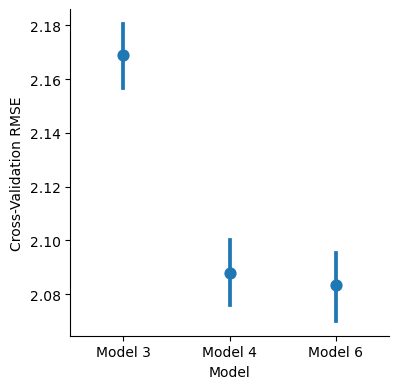

In [427]:
# Save all results in a Data Frame
results_df = pd.DataFrame({'model_name': (['Model 3'] * 10 + ['Model 4'] * 10 +
                                          ['Model 6'] * 10 ), 'rmse': np.concatenate([scores3, scores4, scores6])})

# Visualize the results
sns.catplot(data=results_df, x='model_name', y='rmse', kind='point',
            linestyle='none', errorbar=('ci', 68), height=4)

# Label both axes
plt.xlabel('Model')
plt.ylabel('Cross-Validation RMSE')

plt.show()

#### 1. Which model is the BEST according to CROSS-VALIDATION?

Although Model 6 has a lower RMSE value than Model 4, Model 4 is the better model to use because their 68% confidence intervals overlap one another. This means that they perform very similarly, and since Model 4 is less complex, Model 4 is the better option. 

#### 2. How many regression coefficients are associated with the best model?

There are 35 total regression coefficients associated with Model 4, including the intercept. 

#### 3. Is this model DIFFERENT from the model identified as the BEST according to the training set?

Yes, Model 4 is better according to cross-validation than Model 6. Model 6 was the best model according to the training set because it had the lowest RMSE. However, Model 4 is the better option for cross-validation because Model 6 is more complex and uses interactions and quadratic transformations, but does not improve enough over Model 4 to justify using it.